# WFS controls for operation at ALS beamline 5.3.1
khchan@lbl.gov, francisho@lbl.gov, awojdyla@lbl.gov, walangrizolli@lbl.gov,

We added capture of the beam a the sample. It doesn't quite work but we're close.
We want to acquire a nice grid scanbender/energy without any binning.

We want to add relevant metadata (exposure time , pixel size/camera model, binning) so that we can scale data accordingly (effective flux, effective size)

## Setting up epics/ophyd/bluesky/tiled

In [1]:
from ophyd import EpicsMotor
Obender = EpicsMotor('bl531_esp300:m101_bend_um', name='bender_um')
Obender.low_limit_travel.set(-2000)

# here is the wrapper
#from h01 import mono_energy

Status(obj=EpicsSignal(read_pv='bl531_esp300:m101_bend_um.LLM', name='bender_um_low_limit_travel', parent='bender_um', timestamp=1780029793.865932, auto_monitor=True, string=False, write_pv='bl531_esp300:m101_bend_um.LLM', limits=False, put_complete=False), done=False, success=False)

In [2]:
import sys
sys.path.append('/home/bl531/python/nabla/')
from nabla.nophyd import MonoEnergy, BaslerDetector, BCSMotor

In [3]:
mono_energy = MonoEnergy('', name='mono_energy')  # Empty prefix since motor has full PV

In [4]:
BASLER_FILES_ROOT = "/mnt/data531"
BASLER_5472_IMAGE_DIR = "scans/%Y/%m/%d/basler5472"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs
BASLER_2448_IMAGE_DIR = "scans/%Y/%m/%d/basler2448"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs

try:
    basler_5472 = BaslerDetector(
        "BL531acA5427:",
        name="basler_5472",
        image_dir=BASLER_5472_IMAGE_DIR,
    )

    # Stage signals — set before each acquisition, restored after
    basler_5472.cam.stage_sigs['image_mode']    = 'Single'
    basler_5472.cam.stage_sigs['num_images']    = 1
    basler_5472.cam.stage_sigs['acquire_time']  = 2
    basler_5472.cam.stage_sigs['acquire_period'] = 0.5

    basler_5472.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # Enable TIFF capture when staged
    basler_5472.tiff.stage_sigs['enable']        = 1
    basler_5472.tiff.stage_sigs['auto_save']     = 'Yes'
    basler_5472.tiff.stage_sigs['file_write_mode'] = 'Single'

    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    basler_5472.read_attrs      = ['tiff']
    basler_5472.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531acA5427:'")

try:
    basler_2448 = BaslerDetector(
        "BL531a2A2448:",
        name="basler_2448",
        image_dir=BASLER_2448_IMAGE_DIR,
    )

    # Stage signals — set before each acquisition, restored after
    basler_2448.cam.stage_sigs['image_mode']    = 'Single'
    basler_2448.cam.stage_sigs['num_images']    = 1
    basler_2448.cam.stage_sigs['acquire_time']  = 1
    basler_2448.cam.stage_sigs['acquire_period'] = 1.1
    # basler_2448.cam.stage_sigs['trigger_mode'] = 'Off' 
    basler_2448.cam.stage_sigs['array_callbacks'] = 1
    # basler_2448.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # Enable TIFF capture when staged
    # basler_2448.tiff.stage_sigs['enable']        = 1
    # basler_2448.tiff.stage_sigs['auto_save']     = 'Yes'
    # basler_2448.tiff.stage_sigs['file_write_mode'] = 'Single'
    
    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    # basler_2448.read_attrs      = ['tiff']
    # basler_2448.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531a2A2448:'")

Basler camera connected successfully.
Error instantiating Basler camera: Failed to connect to all signals: basler_2448_cam.cam.gain (BL531a2A2448:cam1:Gain), basler_2448_cam.cam.pixel_format (BL531a2A2448:cam1:PixelFormat), basler_2448_cam.cam.exposure_auto (BL531a2A2448:cam1:ExposureAuto), basler_2448_cam.cam.gain_auto (BL531a2A2448:cam1:GainAuto), basler_2448_cam.cam.acquire_rbv (BL531a2A2448:cam1:Acquire_RBV)
Is the EPICS IOC running? Check PV prefix 'BL531a2A2448:'


In [5]:
import bcs_tcp

# ============================================================
# BCS TCP connection (same as your existing setup)
# ============================================================

ALSU_BOSS_IP = "131.243.80.251"
(host_ip_addr, host_port, host_timeout) = (ALSU_BOSS_IP, 55000, 5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

# Motor id strings (same as before)
bcs_id_linear = 'Galil x.20 A'
bcs_id_rotary = 'Galil x.20 B'

# Quick sanity check
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print(f'linear stage position is {pos_lin_mm} mm')

# ============================================================
# Instantiate BCSMotor ophyd objects
# ============================================================

bcs_linear_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_linear,
    settle_time=0.5,
    tolerance=0.001,
    name='bcs_linear_motor',
)

bcs_rotary_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_rotary,
    settle_time=0.5,
    tolerance=0.01,
    name='bcs_rotary_motor',
)

# ============================================================
# Quick checks
# ============================================================

print(f'Linear motor position : {bcs_linear_motor.position} mm')
print(f'Rotary motor position : {bcs_rotary_motor.position} deg')
print(bcs_linear_motor)
print(bcs_rotary_motor)

linear stage position is 4.423966 mm
Linear motor position : 4.423966 mm
Rotary motor position : 0.0 deg
BCSMotor(name='bcs_linear_motor', motor_id='Galil x.20 A', position=4.4240 mm)
BCSMotor(name='bcs_rotary_motor', motor_id='Galil x.20 B', position=0.0000 mm)


In [6]:
# The queue server must include the "keep_re" parameter which prevents the RE in this startup script from being overwritten

from bluesky import RunEngine

RE = RunEngine({})

from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.callbacks.tiled_writer import TiledWriter
from tiled.server import SimpleTiledServer
from tiled.client import from_uri

#load the api key from env var
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)
tw = TiledWriter(tiled_client, batch_size=1)
## doesnt work yet because the central server is not configured to accept the resource documents with the local file paths. need to patch the resource documents to replace the local path prefix with the central path prefix before sending to central tiled server.

central_tiled_api_key = os.getenv("CENTRAL_API_KEY")
if not central_tiled_api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

central_tiled_client = from_uri("https://tiled.computing.als.lbl.gov/api/v1/metadata/beamlines/bl531/raw", api_key=central_tiled_api_key)


LOCAL_PATH_PREFIX = "mnt/data531"
CENTRAL_PATH_PREFIX = "/global/beegfs/beamlines/bl531/raw"

def patch_ride_filenames(doc: dict):
    """
    a TiledWriter will be sending documents to the central Tiled server.
    For resource documents, we want to patch resource_path;
    Add CENTRAL_PATH_PREFIX in place of LOCAL_PATH_PREFIX as the root key
    Strip LOCAL_PATH_PREFIX from the beginning of resource_path, if it exists
    :param doc_name: Description
    :type doc_name: str
    :param doc: Description
    :type doc: dict
    """    
    resource_path = doc.get("resource_path", "")
    if resource_path.startswith(LOCAL_PATH_PREFIX):
        # Strip LOCAL_PATH_PREFIX and prepend CENTRAL_PATH_PREFIX
        relative_path = resource_path[len(LOCAL_PATH_PREFIX):].lstrip("/")
        new_resource_path = os.path.join(CENTRAL_PATH_PREFIX, relative_path)
        doc["resource_path"] = new_resource_path
        #print(f"Patched resource_path: {resource_path} -> {new_resource_path}")
    return doc

central_tiled_writer = TiledWriter(central_tiled_client, batch_size=1, patches={"resource": patch_ride_filenames})
# uncomment this to connect to central tiled server
# RE.subscribe(central_tiled_writer)

RE.subscribe(tw)

bec = BestEffortCallback()

bec.disable_plots()

# Send all metadata/data captured to the BestEffortCallback.
RE.subscribe(bec)

# add 'baseline' stream with start/stop position of ophyd devices passed into 'sd'
from bluesky.preprocessors import SupplementalData
sd = SupplementalData()
RE.preprocessors.append(sd)
sd.baseline = []
if sd:
#    sd.baseline = [mono_energy, Obender, bcs_linear_motor, basler_5472.cam.stage_sigs['acquire_time']] #for now just adding these two. add more as needed.
    sd.baseline = [mono_energy, Obender, bcs_linear_motor] #for now just adding these two. add more as needed.



[BCSMotor] bcs_linear_motor: moving to 4.5000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 4.5000 mm
[BCSMotor] bcs_linear_motor: moving to 5.0000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 5.0000 mm
[BCSMotor] bcs_linear_motor: moving to 5.5000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 5.5000 mm
[BCSMotor] bcs_linear_motor: moving to 6.0000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 6.0000 mm
[BCSMotor] bcs_linear_motor: moving to 6.5000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 6.5000 mm
[BCSMotor] bcs_linear_motor: moving to 7.0000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 7.0000 mm
[BCSMotor] bcs_linear_motor: moving to 7.5000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 7.5000 mm
[BCSMotor] bcs_linear_motor: moving to 8.0000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 8.0000 mm
[BCSMotor] bcs_linear_motor: moving to 8.5000 mm
[BCSMotor] bcs_linear_motor: done. Final position = 8.5000 mm
[

In [7]:
# from ophyd import (
#     EpicsMotor, Device, Signal, PVPositioner, EpicsSignal, 
#     EpicsSignalRO, Component as Cpt
# )
# class HexapodAxisTz(PVPositioner):
#     """Hexapod vertical (Z) axis positioner"""
#     # Target position
#     setpoint = Cpt(EpicsSignal, 'SYM:HEX01:MOVE_PTP:Tz')
#     # Readback position
#     readback = Cpt(EpicsSignalRO, 'SYM:HEX01:s_uto_tz_RBV')
#     # Done status (True when in position / stopped)
#     done = Cpt(EpicsSignalRO, 'SYM:HEX01:s_hexa:InPosition_RBV')
#     # Execution PV ("GO" button)
#     actuate = Cpt(EpicsSignal, 'SYM:HEX01:MOVE_PTP')
    
#     # Actuation signal ("GO" button)
#     actuate_value = 1  # Value to start motion
# hexapod_motor_Tz = HexapodAxisTz(name='hexapod_motor_Tz')

In [9]:
#Obender.move(-1000)

In [10]:
# from bluesky.plans import scan

# RE(scan([basler_5472], hexapod_motor_Tz, -1, -3, 31))

In [11]:
# uid = '1db9a450-2139-4923-bc86-e3c87932ab92'
# #uid = '8b8ebfcf-125d-46e3-9550-539a9086f067'
# # db = central_tiled_client[uid]
# db = tiled_client[uid]
# images = db['primary']['basler_2448_image'].read()
# bends = db['baseline']['bender_um'].read()
# # metadata
# E_eV = db['baseline']['mono_energy_energy_eV']
# bender_um = db['baseline']['bender_um']
# wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

In [12]:
# %matplotlib qt5
# import matplotlib.pyplot as plt

# plt.imshow(images[0], cmap='gray')
# plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (E_eV[0]*1e-3, bender_um[0], wfs_chip_pos_mm[0]))
# plt.show()

## check data acquisition

In [ ]:
from bluesky import plans as bp
sd.baseline = [mono_energy, Obender, bcs_linear_motor]

cam_model = basler_5472.cam.model.read()['basler_5472_cam_model']['value']
objective_model = "Mitutoyo Plan Apo HR 5X"
exp_time_s = basler_5472.cam.stage_sigs['acquire_time']
pixel_size_um = 2.4
binx = basler_5472.cam.bin_x.read()['basler_5472_cam_bin_x']['value']
biny = basler_5472.cam.bin_y.read()['basler_5472_cam_bin_y']['value']
objective_mag = 5
effective_pixel_size_um = pixel_size_um * binx / objective_mag
md={"exposure time [s]": f"{exp_time_s}", "pixel size [um]": f"{pixel_size_um}", "binning": f"{binx}x{biny}", 
    "effective pixel size [um]": f"{effective_pixel_size_um}", "camera model": f"{cam_model}", "objective model": f"{objective_model}"}

uid = RE(bp.count([basler_5472],num=1,md = md))



Transient Scan ID: 1     Time: 2026-05-28 21:43:29
Persistent Unique Scan ID: '9937dae3-f032-4f8c-8953-abc08ae2c4e5'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8000.184027806925              |
|         mono_energy_mono_angle | 20.755                         |
|                      bender_um | -1999.98627                    |
|               bcs_linear_motor | 4.423966                       |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+
|   seq_num |       time |
+-----------+------------+
|         1 | 21:43:33.4 |
+-----------+------------+
generator count ['9937dae3'] (scan num: 1)
End-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8000.184027806925              |
|         mono_energy_mono_angle | 20.755           

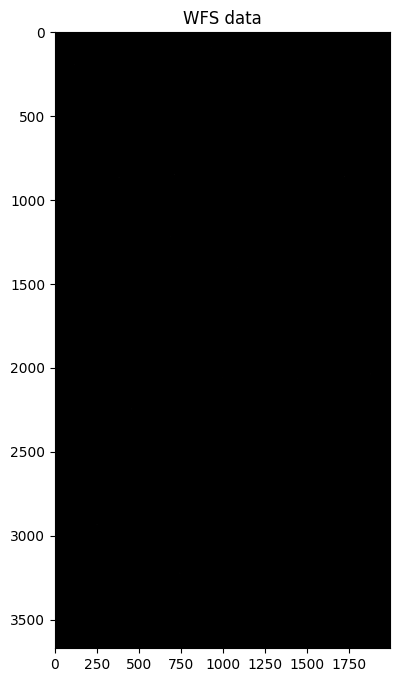

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
uid = uid

db = tiled_client[uid]
images = db['primary']['basler_5472_image'].read()
# bends = db['baseline']['bender_um'].read()
# # metadata
# E_eV = db['baseline']['mono_energy_energy_eV']
# bender_um = db['baseline']['bender_um']
# wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

plt.figure(figsize=(20, 8))
plt.imshow(images[0, :, :], cmap='gray')
plt.title('WFS data')
plt.show()

In [ ]:
# mono_energy.get()
# Obender.get()
bcs_linear_motor.get()

4.418112

In [22]:
from bluesky.plans import grid_scan
#Obender.move(-1484)
RE(grid_scan([basler_5472], mono_energy, 7000, 10000, 7, Obender, -2000, -1600, 5, snake_axes=False))  

('1965f3f8-008e-4cbb-b4a2-7a14d2d92cab',)

In [32]:
# --- Dataset ---
DATASET_ID = '1965f3f8-008e-4cbb-b4a2-7a14d2d92cab'
db = tiled_client[DATASET_ID]

# Metadata
cam_model = basler_5472.cam.model.read()['basler_5472_cam_model']['value']
objective_model = "Mitutoyo Plan Apo HR 5X"
exp_time_s = basler_5472.cam.stage_sigs['acquire_time']
pixel_size_um = 2.4
binx = basler_5472.cam.bin_x.read()['basler_5472_cam_bin_x']['value']
biny = basler_5472.cam.bin_y.read()['basler_5472_cam_bin_y']['value']
objective_mag = 5
effective_pixel_size_um = pixel_size_um * binx / objective_mag
md={"exposure time [s]": f"{exp_time_s}", "pixel size [um]": f"{pixel_size_um}", "binning": f"{binx}x{biny}", 
    "effective pixel size [um]": f"{effective_pixel_size_um}", "camera model": f"{cam_model}", "objective model": f"{objective_model}"}
wfs_chip_pos_mm = bcs_linear_motor.get()

print(f"Camera:          {cam_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")
print(f"WFS chip position (mm): {wfs_chip_pos_mm}")


Camera:          acA5472-5gm
Objective:       Mitutoyo Plan Apo HR 5X
Pixel size:      2.4 µm
Effective pixel: 0.48 µm
Exposure time:   2 s
WFS chip position (mm): 4.400054


In [33]:
# Arrays
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()
bender_um = db['baseline']['bender_um'].read()

print(f"Images shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")

Images shape: (35, 3672, 2000)  (n_frames × height × width)
Energy range: 6999.8 – 9999.8 eV
       shape: (2,)
Bender range: -2000.0 – -1600.0 µm
       shape: (2,)


In [ ]:
from bluesky.plans import grid_scan
#Obender.move(-1484)
RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -2000, -1200, 9, snake_axes=False))  

('337b4bd2-30ef-42bd-812d-223390cb860f',)

In [14]:
# mono_energy.get()
# Obender.get()
bcs_linear_motor.get()

4.418112

In [ ]:
# --- Dataset ---
DATASET_ID = '337b4bd2-30ef-42bd-812d-223390cb860f'
db = tiled_client[DATASET_ID]

# Metadata
cam_model = basler_5472.cam.model.read()['basler_5472_cam_model']['value']
objective_model = "Mitutoyo Plan Apo HR 5X"
exp_time_s = basler_5472.cam.stage_sigs['acquire_time']
pixel_size_um = 2.4
binx = basler_5472.cam.bin_x.read()['basler_5472_cam_bin_x']['value']
biny = basler_5472.cam.bin_y.read()['basler_5472_cam_bin_y']['value']
objective_mag = 5
effective_pixel_size_um = pixel_size_um * binx / objective_mag
md={"exposure time [s]": f"{exp_time_s}", "pixel size [um]": f"{pixel_size_um}", "binning": f"{binx}x{biny}", 
    "effective pixel size [um]": f"{effective_pixel_size_um}", "camera model": f"{cam_model}", "objective model": f"{objective_model}"}
wfs_chip_pos_mm = bcs_linear_motor.get()

print(f"Camera:          {cam_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")
print(f"WFS chip position (mm): {wfs_chip_pos_mm}")

# Arrays
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()
bender_um = db['baseline']['bender_um'].read()

print(f"Images shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")

Camera:          acA5472-5gm
Objective:       Mitutoyo Plan Apo HR 5X
Pixel size:      2.4 µm
Effective pixel: 0.48 µm
Exposure time:   2 s
WFS chip position (mm): 4.400054
Images shape: (99, 3672, 2000)  (n_frames × height × width)
Energy range: 9000.0 – 9999.8 eV
       shape: (2,)
Bender range: -1600.0 – -1200.0 µm
       shape: (2,)


In [9]:
# mono_energy.get()
# Obender.get()
bcs_linear_motor.get()

4.423966

In [10]:
# scan chip linear with 1um step 0,001mm 1000*25 bcs_linear_motor
uid = RE(bp.scan([basler_5472], bcs_linear_motor, 4.5, 16.5, 25, md=md))

In [11]:
uid = RE(bp.count([basler_5472],num=1,md = md))

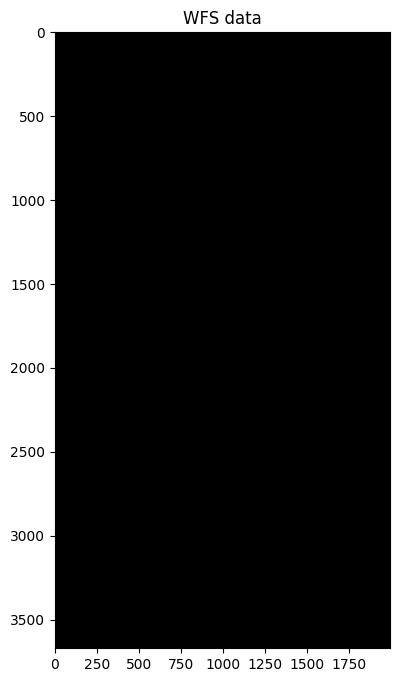

CA.Client.Exception...............................................
    Context: "192.168.10.124:41493"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Fri May 29 2026 11:37:58.487364687
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:34053"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Fri May 29 2026 12:04:10.350347556
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:39171"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Fri May 29 2026 14:09:00.046260426
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:45895"
    Source File: modules/ca/src/client/cac.cpp line 1237


In [12]:
import matplotlib.pyplot as plt
%matplotlib inline
uid = uid

db = tiled_client[uid]
images = db['primary']['basler_5472_image'].read()
# bends = db['baseline']['bender_um'].read()
# # metadata
# E_eV = db['baseline']['mono_energy_energy_eV']
# bender_um = db['baseline']['bender_um']
# wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

plt.figure(figsize=(20, 8))
plt.imshow(images[0, :, :], cmap='gray')
plt.title('WFS data')
plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image

import wfs_live as wfl


In [ ]:
# --- Dataset ---
DATASET_ID = '499e0970-f120-45b2-928e-9567c3885af0'
db = tiled_client[DATASET_ID]

# Metadata

wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
exp_time_s = db.metadata['start']['exposure time [s]']
pixel_size_um = db.metadata['start']['pixel size [um]']
binning = db.metadata['start']['binning']
effective_pixel_size_um = db.metadata['start']['effective pixel size [um]']
camera_model = db.metadata['start']['camera model']
objective_model = db.metadata['start']['objective model']

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning}×)")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")
print(f"WFS chip position (mm): {wfs_chip_pos_mm}")


Camera:          acA5472-5gm
Objective:       Mitutoyo Plan Apo HR 5X
Pixel size:      2.4 µm  (binning: 1x1×)
Effective pixel: 0.48 µm
Exposure time:   2 s
WFS chip position (mm): [4.400054 4.400054]


In [31]:
# Arrays (slow, ~20 seconds to load) 
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()
bender_um = db['baseline']['bender_um'].read()

print(f"Images shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")

Images shape: (1, 3672, 2000)  (n_frames × height × width)
Energy range: 8005.1 – 8005.1 eV
       shape: (2,)
Bender range: -2000.0 – -2000.0 µm
       shape: (2,)


In [46]:
# --- Physical parameters ---
z_gd_m             = 0.3                              # Grating-to-detector distance [m]
grating_pitch_m    = 7e-6                             # Grating pitch from fabrication [m]
dx_m               = float(effective_pixel_size_um) * 1e-6   # Effective pixel size [m]
wavelength_m       = 1.24e-6 / energy_eV        # X-ray wavelength [m]

In [47]:
# ROI: row band over the beam (fringes along x, beam centered ~y=1100)
y_roi = slice(850, 1000)
axis  = 0                     # average over rows → profile along columns

In [ ]:
from bluesky.plans import grid_scan
#Obender.move(-1484)
RE(grid_scan([basler_5472], mono_energy, 7000, 10000, 7, Obender, -2000, -1200, 9, snake_axes=False))  



Transient Scan ID: 2     Time: 2026-05-28 17:36:36
Persistent Unique Scan ID: '2a7ed329-2bd2-498a-9b72-c1b90aadba62'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8000.184027806925              |
|         mono_energy_mono_angle | 20.755                         |
|                      bender_um | -1800.01992                    |
|               bcs_linear_motor | 4.400054                       |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |  bender_um |
+-----------+------------+-----------------------+------------------------+------------+
|         1 | 17:36:45.3 |              6999.820 |                22.8540 | -1999.98786 |
|         2 | 17:36:52.4 |             

In [31]:
bcs_linear_motor.get()

4.400054

In [ ]:
# scan chip linear with 1um step 0,001mm 1000*25 bcs_linear_motor
uid = RE(bp.scan([basler_5472], bcs_linear_motor, 4.01, 8, 3091, md=md))

In [30]:
# from bluesky.plans import grid_scan
# #Obender.move(-1484)
# RE(grid_scan([basler_5472], mono_energy, 7000, 10000, 7, Obender, -2000, -0000,11, snake_axes=False, md=md)) 
print('cleam up because of some tiled errors')
print("Persistent Unique Scan ID: '88dd6a7f-0338-446f-8185-fa9e004add04' - runtime 18min")


cleam up because of some tiled errors
Persistent Unique Scan ID: '88dd6a7f-0338-446f-8185-fa9e004add04' - runtime 18min


In [22]:
# Adding metadata to the baseline
db = tiled_client['88dd6a7f-0338-446f-8185-fa9e004add04']
images = db['primary']['basler_5472_image'].read()
energy = db['baseline']['mono_energy_energy_eV'].read()
bender_um = db['baseline']['bender_um'].read()
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()

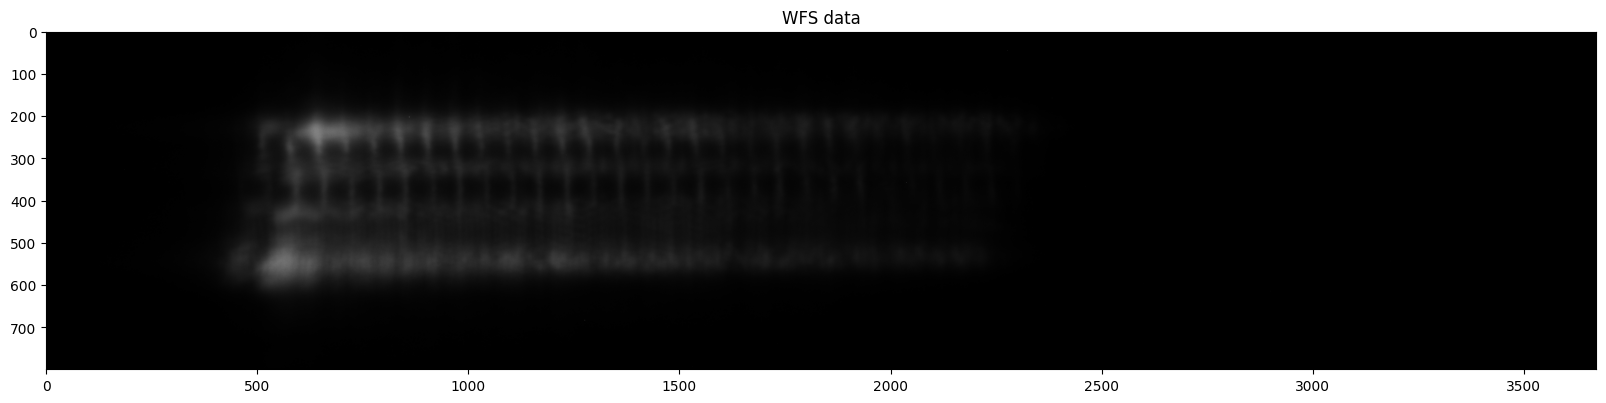

In [24]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(20, 8))
plt.imshow(images[0].T, cmap='gray')
plt.title('WFS data')
plt.show()

In [ ]:
# scan chip linear with 1um step 0,001mm 1000*25 bcs_linear_motor
uid = RE(bp.scan([basler_5472], bcs_linear_motor, 5, 10, 5001, md=md))

A 'deferred pause' has been requested. The RunEngine will pause at the next checkpoint. To pause immediately, hit Ctrl+C again in the next 10 seconds.
